<a href="https://colab.research.google.com/github/abuhussein1504/NYC-Taxi-Trip-Duration/blob/main/NYC_Taxi_Trip_Duration_EDA_annotated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Trip Duration - Exploratory Data Analysis

This notebook explores the [NYC Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration) dataset. The goal here is purely **exploratory** — understanding what the data looks like, spotting data-quality issues, and visualizing patterns in trip duration, distance, speed, and geography across time. Data cleaning and feature engineering for the actual predictive model happen in a separate pipeline; the cleaning steps in this notebook only exist to make the plots below trustworthy (e.g. removing a handful of GPS points that fall outside New York City).

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!pip install -q cartopy==0.25.0

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import DownloadWarning
    HAS_CARTOPY = True
    warnings.filterwarnings('ignore', category=DownloadWarning, module='cartopy.io')
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not installed.")

DATA_PATH = "/content/drive/MyDrive/NYC Taxi Trip Duration/split/train.csv"

DAY_NAMES = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday",
}

BOROUGHS = {
    "Manhattan": (-73.98, 40.75),
    "Brooklyn": (-73.95, 40.65),
    "Queens": (-73.77, 40.72),
    "Bronx": (-73.85, 40.85),
    "Staten Island": (-74.15, 40.58),
}

MAP_EXTENT = [-74.3, -73.4, 40.5, 41.1]
NYC_BBOX = {"lon": (-74.3, -73.4), "lat": (40.5, 41.1)}

## Data loading, quality checks, and feature engineering

The functions below are grouped into three stages:
1. **Load** the raw CSV and parse timestamps.
2. **Check quality** — missing values, duplicate rows, and GPS coordinates that fall outside the NYC area.
3. **Engineer features** used throughout the plots: `pickup_hour`, `pickup_dayofweek`, `day_name`, and `distance` (great-circle distance in miles from pickup to dropoff via the haversine formula).

In [20]:
def load_raw(path):
    return pd.read_csv(path, parse_dates=["pickup_datetime"])


def data_quality_report(df):
    df.info()
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum(), "\n")


def filter_geo_outliers(df, bbox=NYC_BBOX):
    outside = df[
        ~df["pickup_longitude"].between(*bbox["lon"]) |
        ~df["pickup_latitude"].between(*bbox["lat"]) |
        ~df["dropoff_longitude"].between(*bbox["lon"]) |
        ~df["dropoff_latitude"].between(*bbox["lat"])
    ]
    print(f"{len(outside)} rows ({len(outside) / len(df) * 100:.3f}%) "
          f"have coordinates outside the NYC area\n")
    return df.drop(outside.index)


def haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def engineer_features(df):
    df = df.copy()

    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
    df["distance"] = np.log1p((
        haversine(df["pickup_latitude"], df["pickup_longitude"], df["dropoff_latitude"], df["pickup_longitude"]) +
        haversine(df["dropoff_latitude"], df["pickup_longitude"], df["dropoff_latitude"], df["dropoff_longitude"])
    ))

    ordered_days = pd.api.types.CategoricalDtype(categories=DAY_NAMES.values(), ordered=True)
    df["day_name"] = df["pickup_dayofweek"].map(DAY_NAMES).astype(ordered_days)
    return df


def prepare_viz_df(df, max_duration=3600):
    viz_df = df[df["trip_duration"] < max_duration].copy()
    viz_df["log_duration"] = np.log1p(viz_df["trip_duration"])
    viz_df["speed_kph"] = viz_df["distance"] / (viz_df["trip_duration"] / 3600).replace(0, np.nan)
    return viz_df


def duration_and_speed_diagnostics(df, viz_df):
    print(f"Trips >= 1hr: {(df['trip_duration'] >= 3600).sum()} "
          f"({(df['trip_duration'] >= 3600).mean() * 100:.2f}%)\n")

    implausible = viz_df[(viz_df["speed_kph"] > 80) | (viz_df["speed_kph"] == 0)]
    print(f"{len(implausible)} trips with implausible speed (0 or >80mph)")

**What these functions do:**
- `load_raw` — reads `train.csv` and parses `pickup_datetime` as a proper datetime.
- `data_quality_report` — prints column dtypes, missing-value counts, and duplicate-row counts.
- `filter_geo_outliers` — drops rows whose pickup/dropoff coordinates fall outside a rough NYC bounding box.
- `haversine_miles` — computes great-circle distance between two lat/lon points.
- `engineer_features` — adds `pickup_hour`, `pickup_dayofweek`, `day_name`, and `distance`.
- `prepare_viz_df` — filters out trips ≥ 1 hour (to keep plots readable) and computes `log_duration` and `speed_kph`.
- `duration_and_speed_diagnostics` — prints how many trips were excluded as long-duration or implausible-speed outliers.

## Plots

The functions below each produce one figure. They're defined together here and called one at a time further down so each plot can be re-run independently without re-running the whole notebook.

In [21]:
def plot_categorical_breakdowns(df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    df["vendor_id"].value_counts().plot(kind="bar", ax=axes[0], title="Vendor ID")
    df["passenger_count"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Passenger Count")
    df["store_and_fwd_flag"].value_counts().plot(kind="bar", ax=axes[2], title="Store and Fwd Flag")
    plt.tight_layout()
    plt.show()


def plot_correlation_matrix(df):
    num_cols = ["trip_duration", "distance", "passenger_count", "pickup_hour", "pickup_dayofweek"]
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation Matrix")
    plt.show()


def plot_pickup_dropoff_map(viz_df):
    if not HAS_CARTOPY:
        return

    projection = ccrs.PlateCarree()
    fig = plt.figure(figsize=(16, 8))
    ax1 = fig.add_subplot(1, 2, 1, projection=projection)
    ax2 = fig.add_subplot(1, 2, 2, projection=projection)

    optional_features = [
        (cfeature.BORDERS, dict(linestyle=":", edgecolor="gray")),
        (cfeature.STATES, dict(edgecolor="gray")),
        (cfeature.RIVERS, dict(edgecolor="steelblue")),
        (cfeature.LAKES, dict(edgecolor="steelblue")),
    ]

    for ax in (ax1, ax2):
        ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor="lightyellow")
        ax.add_feature(cfeature.OCEAN, facecolor="skyblue")
        ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.5)
        for feature, kwargs in optional_features:
            try:
                ax.add_feature(feature, **kwargs)
            except Exception as e:
                print(f"Skipping a map feature (likely no internet for shapefile download): {e}")

    sc1 = ax1.scatter(
        viz_df["pickup_longitude"], viz_df["pickup_latitude"],
        c=viz_df["log_duration"], cmap="viridis", s=2, alpha=0.6,
        transform=ccrs.PlateCarree(), zorder=1,
    )
    ax1.set_title("Pickup Locations Colored by Trip Duration (log scale)")

    sc2 = ax2.scatter(
        viz_df["dropoff_longitude"], viz_df["dropoff_latitude"],
        c=viz_df["log_duration"], cmap="viridis", s=2, alpha=0.6,
        transform=ccrs.PlateCarree(), zorder=1,
    )
    ax2.set_title("Dropoff Locations Colored by Trip Duration (log scale)")

    for ax in (ax1, ax2):
        for borough, (lon, lat) in BOROUGHS.items():
            ax.text(lon, lat, borough, fontsize=10, color="black", ha="center", va="center", zorder=2)

    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=plt.Axes)
    cbar = plt.colorbar(sc2, cax=cax)
    cbar.set_label("log(1 + Trip Duration)", rotation=270, labelpad=15)

    plt.suptitle("Pickup and Dropoff Locations Over Map (New York Area)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()


def plot_duration_histogram(viz_df):
    plt.figure(figsize=(10, 5))
    sns.histplot(viz_df["log_duration"], bins=100, kde=True, color="orange")
    plt.title("Log-Transformed Trip Duration")
    plt.xlabel("log(Trip Duration + 1)")
    plt.ylabel("Frequency")
    plt.show()


def plot_time_heatmaps(viz_df, i):
    metrics = [
        ("trip_duration", "Average Trip Duration by Day and Hour", "Avg Duration (sec)"),
        ("distance", "Average Trip Distance by Day and Hour", "Avg Distance (miles)"),
        ("speed_kph", "Average Trip Speed by Day and Hour", "Avg Speed (mph)"),
    ]

    value_col, title, cbar_label = metrics[i]

    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

    pivot = viz_df.pivot_table(
        index="day_name", columns="pickup_hour", values=value_col,
        aggfunc="mean", observed=True,
    )
    sns.heatmap(pivot, cmap="YlGnBu", annot=False, ax=ax, cbar_kws={"label": cbar_label})
    ax.set_title(title)
    ax.set_xlabel("Hour of Day (0 = midnight)")
    ax.set_ylabel("Day of Week")
    plt.setp(ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    plt.show()


def plot_distance_vs_duration(viz_df):
    plt.figure(figsize=(10, 6))
    plt.scatter(viz_df["distance"], viz_df["trip_duration"], alpha=0.6)
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Trip Duration vs Distance (Log Scale)")
    plt.xlabel("Log Distance (miles)")
    plt.ylabel("Log Trip Duration (sec)")
    plt.grid(True)
    plt.show()

With the data pipeline and plotting functions defined, the cells below run the pipeline once and then call each plotting function in turn.

In [22]:
train_raw = load_raw(DATA_PATH)

data_quality_report(train_raw)
train_clean = filter_geo_outliers(train_raw)

train = engineer_features(train_clean)
viz_df = prepare_viz_df(train)

duration_and_speed_diagnostics(train, viz_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1000000 non-null  object        
 1   vendor_id           1000000 non-null  int64         
 2   pickup_datetime     1000000 non-null  datetime64[ns]
 3   passenger_count     1000000 non-null  int64         
 4   pickup_longitude    1000000 non-null  float64       
 5   pickup_latitude     1000000 non-null  float64       
 6   dropoff_longitude   1000000 non-null  float64       
 7   dropoff_latitude    1000000 non-null  float64       
 8   store_and_fwd_flag  1000000 non-null  object        
 9   trip_duration       1000000 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 76.3+ MB

Missing values:
id                    0
vendor_id             0
pickup_datetime       0
passenger_count      

**Data quality summary:** the raw dataset has 1,458,644 trips across 11 columns with **no missing values and no duplicate rows** — this dataset is unusually clean. Only 258 rows (0.018%) had GPS coordinates outside the NYC area and were dropped. For visualization, trips lasting an hour or longer (12,267 trips, 0.84% of the data) are excluded so the histograms and heatmaps aren't stretched by a long tail of extreme outliers. Separately, 5,935 trips show an implausible speed (either 0 mph or over 80 mph), most likely due to GPS or timestamp errors rather than real driving — worth keeping in mind when reading the speed heatmap below.

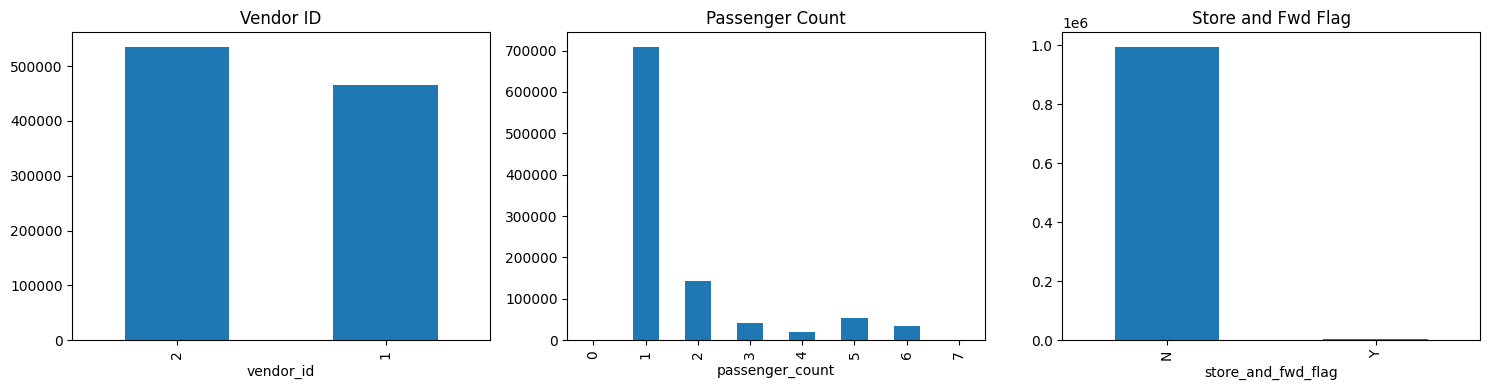

In [23]:
plot_categorical_breakdowns(train)

**Vendor, passenger count, and store-and-forward flag:** trips are split between two vendors, the vast majority of rides carry a single passenger with a long tail down to larger group rides, and almost all trips have `store_and_fwd_flag = N` (meaning the trip data was sent to the server immediately rather than being stored on the vehicle due to a lost connection).

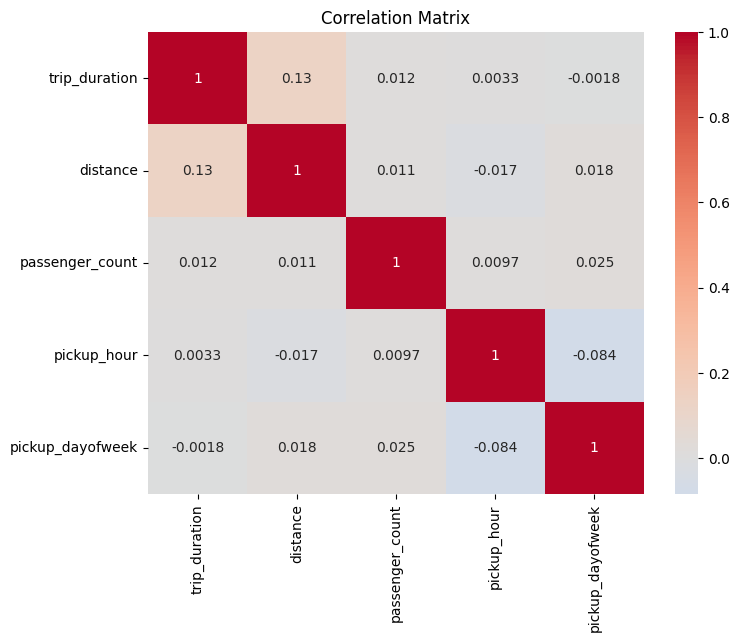

In [24]:
plot_correlation_matrix(train)

**Correlation matrix:** `distance` has the strongest relationship with `trip_duration` of the numeric features, which makes sense — longer trips take longer. `passenger_count`, `pickup_hour`, and `pickup_dayofweek` show weak linear correlation with duration on their own; their effect shows up more in the time-of-day/day-of-week heatmaps further down than in a simple linear correlation.

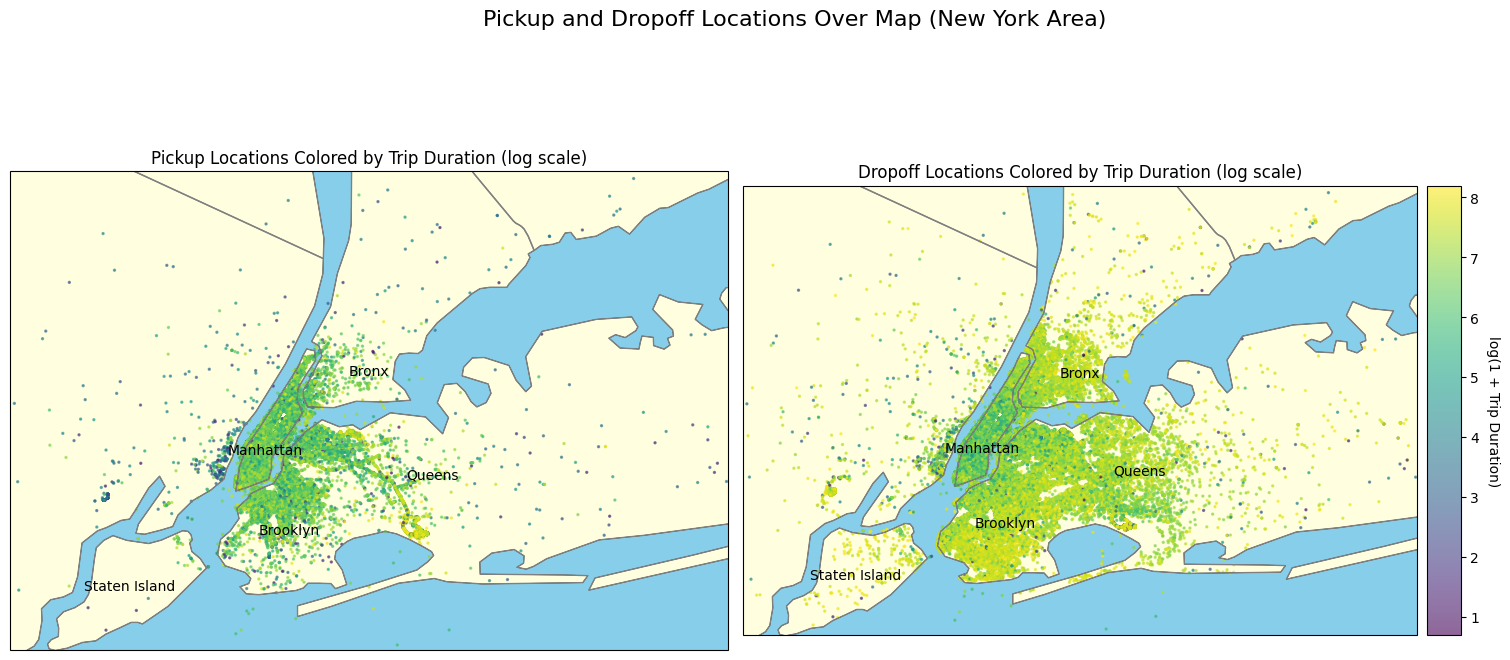

In [25]:
plot_pickup_dropoff_map(viz_df)

**Pickup and dropoff maps:** both pickups and dropoffs are heavily concentrated in Manhattan, with a visible secondary cluster around LaGuardia and JFK airports (the streak of trips toward Queens). Trips with longer duration (brighter/yellow points) skew toward the airport routes and the outer boroughs, while short, dark-colored trips dominate dense Manhattan traffic.

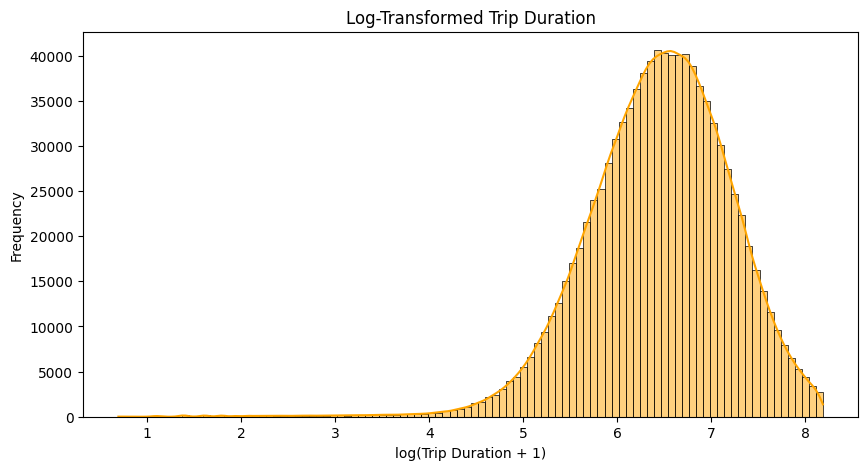

In [26]:
plot_duration_histogram(viz_df)

**Trip duration distribution:** after the log transform, trip duration is roughly bell-shaped and much easier to work with than the raw, heavily right-skewed duration — this is why models built on this data typically predict `log(1 + trip_duration)` rather than the raw duration directly.

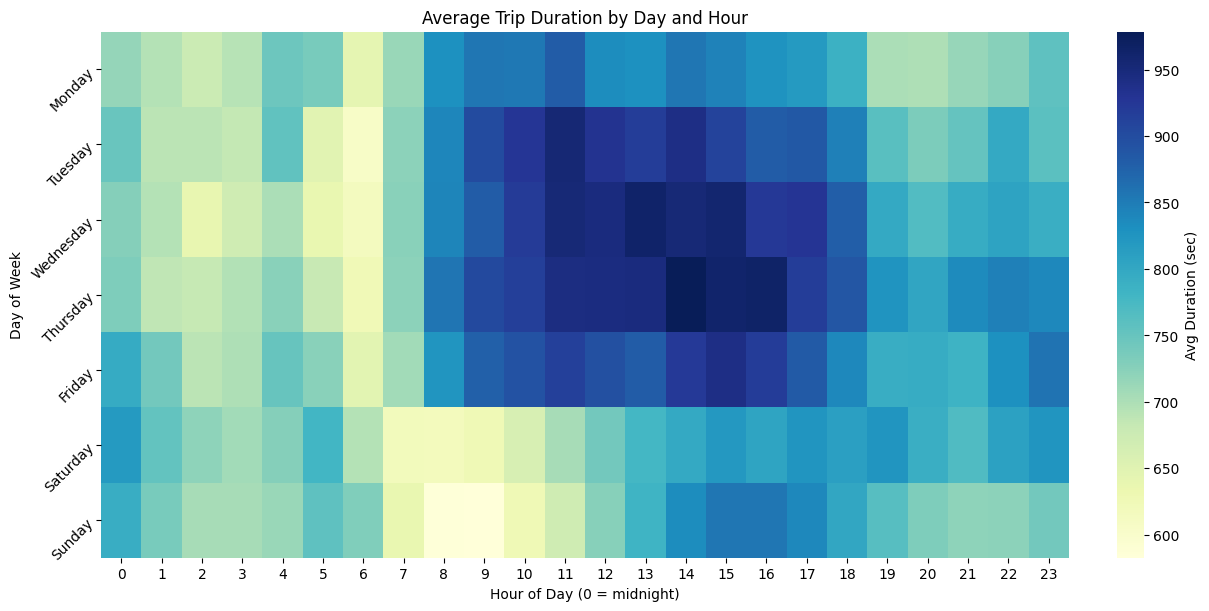

In [27]:
plot_time_heatmaps(viz_df, 0)

**Average duration by day and hour:** durations are longest on weekday afternoons (roughly 11am-6pm, peaking around Thursday), which lines up with daytime traffic congestion. Early-morning hours (around 5-7am) and weekends have noticeably shorter average durations.

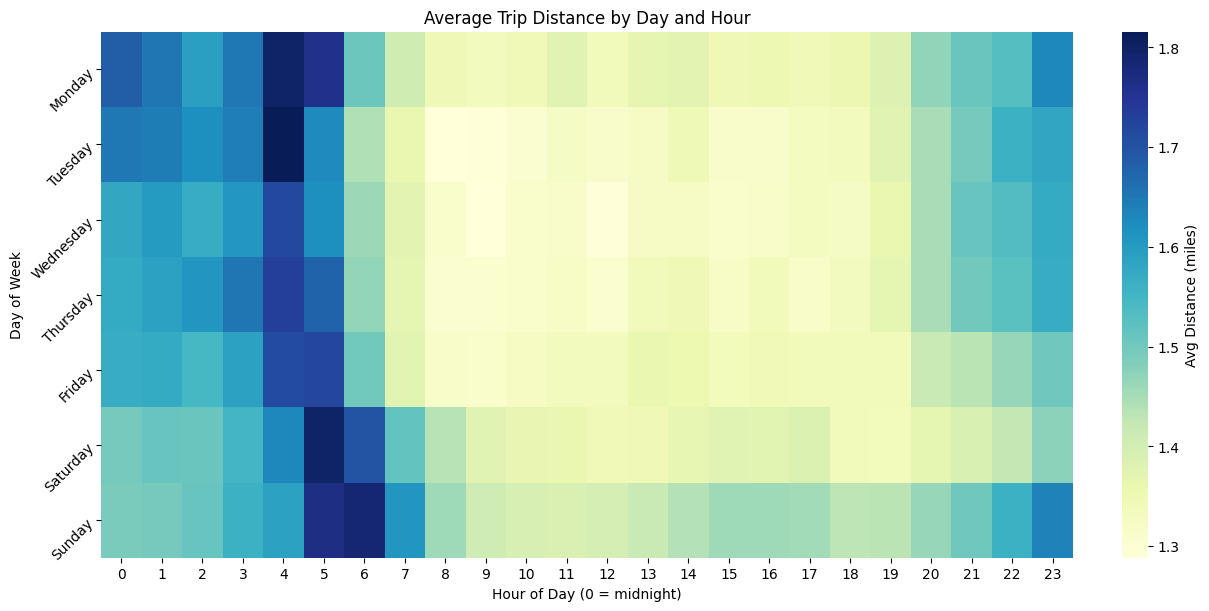

In [28]:
plot_time_heatmaps(viz_df, 1)

**Average distance by day and hour:** distance is comparatively flat across the week — people don't travel much farther on one day than another — with a modest uptick in the early morning hours, consistent with more airport/long-haul trips when there's less short-hop local traffic.

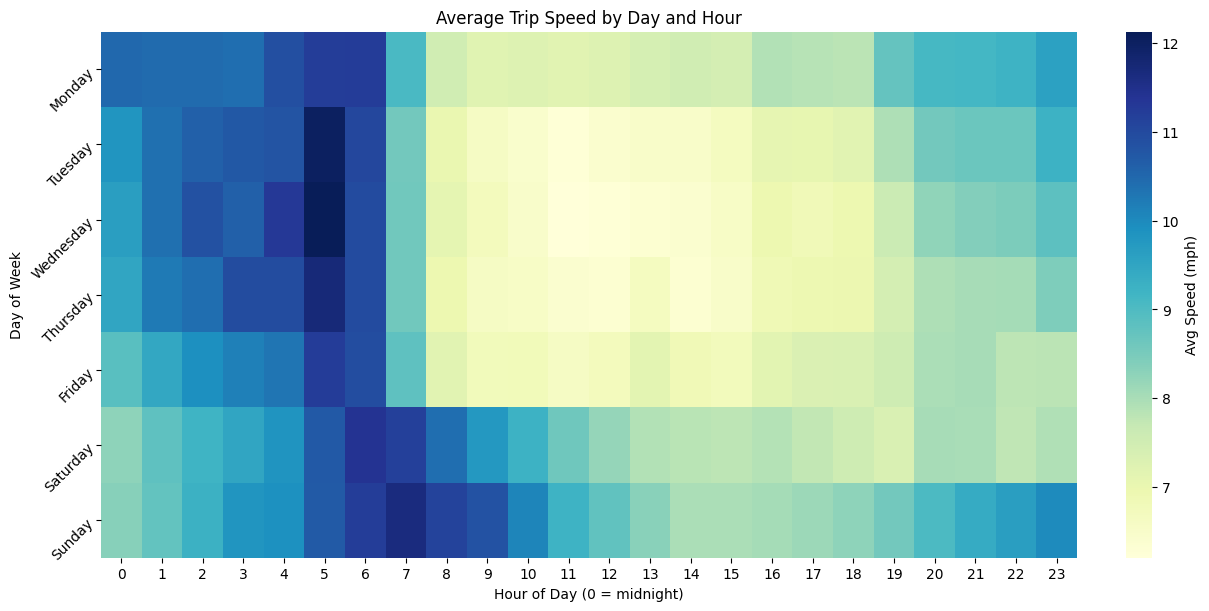

In [29]:
plot_time_heatmaps(viz_df, 2)

**Average speed by day and hour:** this is the clearest time pattern of the three. Speed peaks in the early morning hours (roughly 2-5am) when the roads are empty, and drops sharply during weekday rush hours — the same hours where the duration heatmap shows its peak. This is a good sanity check: distance stays flat, duration rises, and speed falls, all pointing to congestion rather than people simply traveling farther.

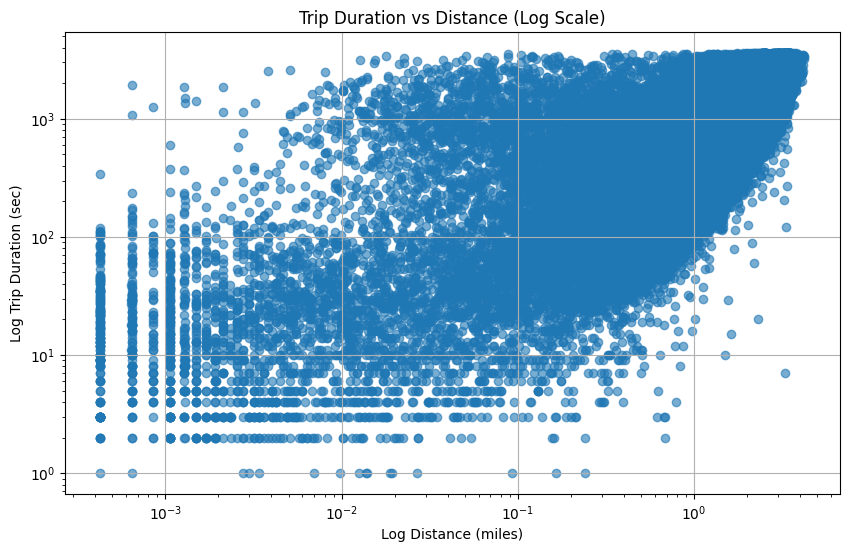

In [30]:
plot_distance_vs_duration(viz_df)

**Duration vs. distance:** on a log-log scale the relationship is roughly linear, as expected, but with a lot of vertical spread at any given distance — two trips covering the same distance can take very different amounts of time depending on traffic, time of day, and route. This spread is exactly what the day/hour heatmaps above help explain.

## Summary

Key takeaways from this exploration:
- The dataset is very clean (no missing values, no duplicates); only a tiny fraction of rows needed dropping for bad GPS coordinates.
- Trip demand and duration are dominated by Manhattan traffic patterns, with a clear secondary cluster around the airports.
- Duration is driven far more by **when** a trip happens (time of day, day of week, i.e. traffic) than by distance alone — distance stays roughly flat across the week while duration and speed swing widely.
- ~0.84% of trips last over an hour and ~0.4% show implausible speeds; both are worth a decision (cap, remove, or flag) in the modeling pipeline, separate from this notebook.

This notebook is intentionally scoped to exploration and visualization. Cleaning, encoding, and feature selection for the predictive model itself live in a separate pipeline.